<a href="https://colab.research.google.com/github/mertmisirli/1_Tensorflow/blob/main/data_10_Feature_Engineering_for_Machine_Learning_in_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
/
/




Daily XP
390
Exercise
Exercise
Getting to know your data
Pandas is one the most popular packages used to work with tabular data in Python. It is generally imported using the alias pd and can be used to load a CSV (or other delimited files) using read_csv().

You will be working with a modified subset of the Stackoverflow survey response data in the first three chapters of this course. This dataset records the details, and preferences of thousands of users of the StackOverflow website.

Instructions 1/4
25 XP
1
2
3
4
Import the pandas library as pd.
so_survey_csv contains the URL to a CSV file. Import it using Pandas into so_survey_df.

Take Hint (-7 XP)
script.py
12345
# Import pandas
import ____ as ____

# Import so_survey_csv into so_survey_df
so_survey_df = ____(so_survey_csv)
IPython Shell
Slides
In [1]:


In [ ]:
# Import pandas
import pandas as pd

# Import so_survey_csv into so_survey_df
so_survey_df = pd.read_csv(so_survey_csv)

In [ ]:
Print the first five rows of so_survey_df.




In [ ]:
# Import pandas
import pandas as pd

# Import so_survey_csv into so_survey_df
so_survey_df = pd.read_csv(so_survey_csv)

# Print the first five rows of the DataFrame
print(so_survey_df.head())

In [ ]:
Print the data type of each column in so_survey_df.




In [ ]:
# Import pandas
import pandas as pd

# Import so_survey_csv into so_survey_df
so_survey_df = pd.read_csv(so_survey_csv)

# Print the first five rows of the DataFrame
print(so_survey_df.head())

# Print the data type of each column
print(so_survey_df.dtypes)

In [ ]:
Question
What type of data is the ConvertedSalary column?

Possible answers


Datetime

Numeric

String

Boolean



In [ ]:
Numeric

In [ ]:
/
/




Daily XP
490
Exercise
Exercise
Selecting specific data types
Often a dataset will contain columns with several different data types (like the one you are working with). The majority of machine learning models require you to have a consistent data type across features. Similarly, most feature engineering techniques are applicable to only one type of data at a time. For these reasons among others, you will often want to be able to access just the columns of certain types when working with a DataFrame.

The DataFrame (so_survey_df) from the previous exercise is available in your workspace.

Instructions
100 XP
Create a subset of so_survey_df consisting of only the numeric (int and float) columns.
Print the column names contained in so_survey_df_num.

Take Hint (-30 XP)
script.py
12345
# Create subset of only the numeric columns
so_numeric_df = so_survey_df.____(____=[____])

# Print the column names contained in so_survey_df_num
print(so_numeric_df.____)
IPython Shell
Slides
In [1]:


In [ ]:
# Create subset of only the numeric columns
so_numeric_df = so_survey_df.select_dtypes(include=['int', 'float'])

# Print the column names contained in so_survey_df_num
print(so_numeric_df.columns)

In [ ]:
/
/




Daily XP
490
Exercise
Exercise
One-hot encoding and dummy variables
To use categorical variables in a machine learning model, you first need to represent them in a quantitative way. The two most common approaches are to one-hot encode the variables using or to use dummy variables. In this exercise, you will create both types of encoding, and compare the created column sets. We will continue using the same DataFrame from previous lesson loaded as so_survey_df and focusing on its Country column.

Instructions 1/2
50 XP
1
One-hot encode the Country column, adding "OH" as a prefix for each column.


Take Hint (-15 XP)
2
Create dummy variables for the Country column, adding "DM" as a prefix for each column.

script.py
12345
# Convert the Country column to a one hot encoded Data Frame
one_hot_encoded = ____(____, ____=['Country'], prefix='OH')

# Print the columns names
print(one_hot_encoded.columns)
IPython Shell
Slides
In [1]:


In [ ]:
# Convert the Country column to a one hot encoded Data Frame
one_hot_encoded = pd.get_dummies(so_survey_df, columns=['Country'], prefix='OH')

# Print the columns names
print(one_hot_encoded.columns)

In [ ]:
Create dummy variables for the Country column, adding "DM" as a prefix for each column.




In [ ]:
# Create dummy variables for the Country column
dummy = pd.get_dummies(so_survey_df, columns=["Country"], drop_first=True, prefix='DM')

# Print the columns names
print(dummy.columns)

In [ ]:
/
/




Daily XP
590
Exercise
Exercise
Dealing with uncommon categories
Some features can have many different categories but a very uneven distribution of their occurrences. Take for example Data Science's favorite languages to code in, some common choices are Python, R, and Julia, but there can be individuals with bespoke choices, like FORTRAN, C etc. In these cases, you may not want to create a feature for each value, but only the more common occurrences.

Instructions 1/3
35 XP
1
2
3
Extract the Country column of so_survey_df as a series and assign it to countries.
Find the counts of each category in the newly created countries series.

Take Hint (-10 XP)
script.py
12345678
# Create a series out of the Country column
countries = so_survey_df.____

# Get the counts of each category
country_counts = countries.____

# Print the count values for each category
print(country_counts)
IPython Shell
Slides
In [1]:


In [ ]:
# Create a series out of the Country column
countries = so_survey_df["Country"]

# Get the counts of each category
country_counts = countries.value_counts()

# Print the count values for each category
print(country_counts)

In [ ]:
Create a mask for values occurring less than 10 times in country_counts.
Print the first 5 rows of the mask.



In [ ]:
# Create a series out of the Country column
countries = so_survey_df['Country']

# Get the counts of each category
country_counts = countries.value_counts()

# Create a mask for only categories that occur less than 10 times
mask = countries.isin(country_counts[country_counts < 10].index)

# Print the top 5 rows in the mask series
print(mask.head())

In [ ]:
Label values occurring less than the mask cutoff as 'Other'.
Print the new category counts in countrie

In [ ]:
# Create a series out of the Country column
countries = so_survey_df['Country']

# Get the counts of each category
country_counts = countries.value_counts()

# Create a mask for only categories that occur less than 10 times
mask = countries.isin(country_counts[country_counts < 10].index)

# Label all other categories as Other
countries[mask] = 'Other'

# Print the updated category counts
print(pd.value_counts(countries))

In [ ]:
/
/




Daily XP
660
Exercise
Exercise
Binarizing columns
While numeric values can often be used without any feature engineering, there will be cases when some form of manipulation can be useful. For example on some occasions, you might not care about the magnitude of a value but only care about its direction, or if it exists at all. In these situations, you will want to binarize a column. In the so_survey_df data, you have a large number of survey respondents that are working voluntarily (without pay). You will create a new column titled Paid_Job indicating whether each person is paid (their salary is greater than zero).

Instructions
100 XP
Create a new column called Paid_Job filled with zeros.
Replace all the Paid_Job values with a 1 where the corresponding ConvertedSalary is greater than 0.

Take Hint (-30 XP)
script.py
12345678
# Create the Paid_Job column filled with zeros
so_survey_df[____] = ____

# Replace all the Paid_Job values where ConvertedSalary is > 0
so_survey_df.____[____, 'Paid_Job'] = 1

# Print the first five rows of the columns
print(so_survey_df[['Paid_Job', 'ConvertedSalary']].head())
IPython Shell
Slides
In [1]:


In [ ]:
# Create the Paid_Job column filled with zeros
so_survey_df["Paid_Job"] = 0

# Replace all the Paid_Job values where ConvertedSalary is > 0
so_survey_df.loc[so_survey_df['ConvertedSalary'] > 0, 'Paid_Job'] = 1

# Print the first five rows of the columns
print(so_survey_df[['Paid_Job', 'ConvertedSalary']].head())


In [ ]:
/
/




Daily XP
760
Exercise
Exercise
Binning values
For many continuous values you will care less about the exact value of a numeric column, but instead care about the bucket it falls into. This can be useful when plotting values, or simplifying your machine learning models. It is mostly used on continuous variables where accuracy is not the biggest concern e.g. age, height, wages.

Bins are created using pd.cut(df['column_name'], bins) where bins can be an integer specifying the number of evenly spaced bins, or a list of bin boundaries.

Instructions 1/2
50 XP
1
Bin the value of the ConvertedSalary column in so_survey_df into 5 equal bins, in a new column called equal_binned.


Take Hint (-15 XP)
2
Bin the ConvertedSalary column using the boundaries in the list bins and label the bins using labels.

script.py
12345
# Bin the continuous variable ConvertedSalary into 5 bins
so_survey_df['equal_binned'] = ____(so_survey_df['ConvertedSalary'], ____)

# Print the first 5 rows of the equal_binned column
print(so_survey_df[['equal_binned', 'ConvertedSalary']].head())
IPython Shell
Slides
In [1]:


In [ ]:
# Bin the continuous variable ConvertedSalary into 5 bins
so_survey_df['equal_binned'] = pd.cut(so_survey_df['ConvertedSalary'], bins=5)

# Print the first 5 rows of the equal_binned column
print(so_survey_df[['equal_binned', 'ConvertedSalary']].head())


In [ ]:
Take Hint (-15 XP)
2
Bin the ConvertedSalary column using the boundaries in the list bins and label the bins using labels.


In [ ]:
# Bin the continuous variable ConvertedSalary using these boundaries
so_survey_df['boundary_binned'] = pd.cut(so_survey_df['ConvertedSalary'],
                                         bins=bins,
                                         labels=labels)

# Print the first 5 rows of the boundary_binned column
print(so_survey_df[['boundary_binned', 'ConvertedSalary']].head())


In [ ]:
/
/




Daily XP
810
Exercise
Exercise
How sparse is my data?
Most datasets contain missing values, often represented as NaN (Not a Number). If you are working with Pandas you can easily check how many missing values exist in each column.

Let's find out how many of the developers taking the survey chose to enter their age (found in the Age column of so_survey_df) and their gender (Gender column of so_survey_df).

Instructions 1/2
50 XP
1
2
Subset the DataFrame to only include the 'Age' and 'Gender' columns.
Print the number of non-missing values in both columns.

Take Hint (-15 XP)
script.py
12345
# Subset the DataFrame
sub_df = ____

# Print the number of non-missing values
print(sub_df.____)
IPython Shell
Slides
In [1]:


In [ ]:
# Subset the DataFrame
sub_df = so_survey_df[["Age","Gender"]]

# Print the number of non-missing values
print(sub_df.count())

In [ ]:
Age       999
Gender    693

In [ ]:
Question
Based on the results, how many non-missing entries are there in the Gender column?

Possible answers


999

693

In [ ]:
/
/




Daily XP
910
Exercise
Exercise
Finding the missing values
While having a summary of how much of your data is missing can be useful, often you will need to find the exact locations of these missing values. Using the same subset of the StackOverflow data from the last exercise (sub_df), you will show how a value can be flagged as missing.

Instructions 1/3
35 XP
1
Print the first 10 entries of the DataFrame.


Take Hint (-10 XP)
2
Print the locations of the missing values in the first 10 rows.

3
Print the locations of the non-missing values in the first 10 rows.

script.py
12
# Print the top 10 entries of the DataFrame
print(sub_df.____)
IPython Shell
Slides
In [1]:


In [ ]:
# Print the top 10 entries of the DataFrame
print(sub_df.head(10))

In [ ]:
Print the locations of the missing values in the first 10 rows.






In [ ]:
# Print the locations of the missing values
print(sub_df.head(10).isnull())

In [ ]:
Print the locations of the non-missing values in the first 10 rows.





In [ ]:
# Print the locations of the non-missing values
print(sub_df.head(10).notnull())

In [ ]:
/
/




Daily XP
967
Exercise
Exercise
Listwise deletion
The simplest way to deal with missing values in your dataset when they are occurring entirely at random is to remove those rows, also called 'listwise deletion'.

Depending on the use case, you will sometimes want to remove all missing values in your data while other times you may want to only remove a particular column if too many values are missing in that column.

Instructions 1/4
25 XP
1
Print the number of rows and columns in so_survey_df.


Take Hint (-7 XP)
2
Drop all rows with missing values in so_survey_df.

3
Drop all columns with missing values in so_survey_df.

4
Drop all rows in so_survey_df where 'Gender' is missing.

script.py
12
# Print the number of rows and columns
print(so_survey_df.____)
IPython Shell
Slides
In [1]:


In [ ]:
# Print the number of rows and columns
print(so_survey_df.shape)

In [ ]:
Drop all rows with missing values in so_survey_df.




In [ ]:
# Create a new DataFrame dropping all incomplete rows
no_missing_values_rows = so_survey_df.dropna()

# Print the shape of the new DataFrame
print(no_missing_values_rows.shape)

In [ ]:
Drop all columns with missing values in so_survey_df.




In [ ]:
# Create a new DataFrame dropping all columns with any missing values
no_missing_values_cols = so_survey_df.dropna(axis=1, how='any')

# Print the shape of the new DataFrame
print(no_missing_values_cols.shape)


In [ ]:
Drop all rows in so_survey_df where 'Gender' is missing.




In [ ]:
# Drop all rows where Gender is missing
no_gender = so_survey_df.dropna(subset=['Gender'])

# Print the shape of the new DataFrame
print(no_gender.shape)

In [ ]:
/
/




Daily XP
1043
Exercise
Exercise
Replacing missing values with constants
While removing missing data entirely maybe a correct approach in many situations, this may result in a lot of information being omitted from your models.

You may find categorical columns where the missing value is a valid piece of information in itself, such as someone refusing to answer a question in a survey. In these cases, you can fill all missing values with a new category entirely, for example 'No response given'.

Instructions 1/2
50 XP
1
2
Print the count of occurrences of each category in so_survey_df's Gender column.


Take Hint (-15 XP)
script.py
12
# Print the count of occurrences
print(so_survey_df['Gender']____)
IPython Shell
Slides
In [1]:


In [ ]:
# Print the count of occurrences
print(so_survey_df['Gender'].value_counts())

In [ ]:
Replace all missing values in the Gender column with the string 'Not Given'. Make changes to the original DataFrame.




In [ ]:
# Replace missing values
so_survey_df['Gender'].fillna(value='Not Given', inplace=True)

# Print the count of each value
print(so_survey_df['Gender'].value_counts())

In [ ]:
/
/




Daily XP
1093
Exercise
Exercise
Filling continuous missing values
In the last lesson, you dealt with different methods of removing data missing values and filling in missing values with a fixed string. These approaches are valid in many cases, particularly when dealing with categorical columns but have limited use when working with continuous values. In these cases, it may be most valid to fill the missing values in the column with a value calculated from the entries present in the column.

Instructions 1/3
35 XP
1
2
3
Print the first five rows of the StackOverflowJobsRecommend column of so_survey_df.


Take Hint (-10 XP)
script.py
12
# Print the first five rows of StackOverflowJobsRecommend column
print(____)
IPython Shell
Slides
In [1]:


In [ ]:
# Print the first five rows of StackOverflowJobsRecommend column
print(so_survey_df["StackOverflowJobsRecommend"].head())

In [ ]:
Replace the missing values in the StackOverflowJobsRecommend column with its mean. Make changes directly to the original DataFrame.




In [ ]:
# Fill missing values with the mean
so_survey_df['StackOverflowJobsRecommend'].fillna(so_survey_df['StackOverflowJobsRecommend'].mean(), inplace=True)

# Print the first five rows of StackOverflowJobsRecommend column
print(so_survey_df['StackOverflowJobsRecommend'].head())

In [ ]:
Round the decimal values that you introduced in the StackOverflowJobsRecommend column.




In [ ]:
# Fill missing values with the mean
so_survey_df['StackOverflowJobsRecommend'].fillna(so_survey_df['StackOverflowJobsRecommend'].mean(), inplace=True)

# Round the StackOverflowJobsRecommend values
so_survey_df['StackOverflowJobsRecommend'] = round(so_survey_df['StackOverflowJobsRecommend'])

# Print the top 5 rows
print(so_survey_df['StackOverflowJobsRecommend'].head())

In [ ]:
/
/




Daily XP
1193
Imputing values in predictive models
When working with predictive models you will often have a separate train and test DataFrames. In these cases you want to ensure no information from your test set leaks into your train set. When filling missing values in data to be used in these situations how should approach the two datasets?

Answer the question
50XP
Possible Answers
Select one answer

Only fill the train set.
Press
1

Only fill the test set.
Press
2

Apply the measures of central tendency (mean/median etc.) calculated on the train set to both the train and test sets.
Press
3

Apply the measures of central tendency (mean/median etc.) calculated on the test set to both the train and test sets.
Press
4

Apply the measures of central tendency (mean/median etc.) calculated on the train set to the train set, and the measures calculated on the test set, to the test set.
Press
5

Take Hint (-15 XP)

Submit Answer


In [ ]:
Apply the measures of central tendency (mean/median etc.) calculated on the train set to both the train and test sets.
Press
3

In [ ]:
/
/




Daily XP
1243
Exercise
Exercise
Dealing with stray characters (I)
In this exercise, you will work with the RawSalary column of so_survey_df which contains the wages of the respondents along with the currency symbols and commas, such as $42,000. When importing data from Microsoft Excel, more often that not you will come across data in this form.

Instructions 1/2
50 XP
1
Remove the commas (,) from the RawSalary column.


Take Hint (-15 XP)
2
Remove the dollar ($) signs from the RawSalary column.

script.py
12
# Remove the commas in the column
so_survey_df['RawSalary'] = so_survey_df['RawSalary'].____(',', '')
IPython Shell
Slides
In [1]:


In [ ]:
# Remove the commas in the column
so_survey_df['RawSalary'] = so_survey_df['RawSalary'].replace(',', '')

In [ ]:
/
/




Daily XP
1278
Exercise
Exercise
Dealing with stray characters (I)
In this exercise, you will work with the RawSalary column of so_survey_df which contains the wages of the respondents along with the currency symbols and commas, such as $42,000. When importing data from Microsoft Excel, more often that not you will come across data in this form.

Instructions 2/2
50 XP
Remove the commas (,) from the RawSalary column.

2
Remove the dollar ($) signs from the RawSalary column.


Take Hint (-15 XP)
script.py
12
# Remove the dollar signs in the column
so_survey_df['RawSalary'] = so_survey_df['RawSalary'].____
IPython Shell
Slides
In [1]:


In [ ]:
# Remove the commas in the column
so_survey_df['RawSalary'] = so_survey_df['RawSalary'].str.replace(',', '')

In [ ]:
Remove the dollar ($) signs from the RawSalary column.




In [ ]:
# Remove the dollar signs in the column
so_survey_df['RawSalary'] = so_survey_df['RawSalary'].str.replace('$', '')

In [ ]:
/
/




Daily XP
1328
Exercise
Exercise
Dealing with stray characters (II)
In the last exercise, you could tell quickly based off of the df.head() call which characters were causing an issue. In many cases this will not be so apparent. There will often be values deep within a column that are preventing you from casting a column as a numeric type so that it can be used in a model or further feature engineering.

One approach to finding these values is to force the column to the data type desired using pd.to_numeric(), coercing any values causing issues to NaN, Then filtering the DataFrame by just the rows containing the NaN values.

Try to cast the RawSalary column as a float and it will fail as an additional character can now be found in it. Find the character and remove it so the column can be cast as a float.

Instructions 1/2
50 XP
1
2
Attempt to convert the RawSalary column of so_survey_df to numeric values coercing all failures into null values.
Find the indexes of the rows containing NaNs.
Print the rows in RawSalary based on these indexes.

Take Hint (-15 XP)
script.py
12345678
# Attempt to convert the column to numeric values
numeric_vals = ____(so_survey_df['RawSalary'], errors='coerce')

# Find the indexes of missing values
idx = ____

# Print the relevant rows
print(so_survey_df['RawSalary']____)
IPython Shell
Slides
In [1]:


In [ ]:
# Attempt to convert the column to numeric values
numeric_vals = pd.to_numeric(so_survey_df['RawSalary'], errors='coerce')

# Find the indexes of missing values
idx = numeric_vals.isna()

# Print the relevant rows
print(so_survey_df['RawSalary'][idx])

In [ ]:
Did you notice the pound (£) signs in the RawSalary column? Remove these signs like you did in the previous exercise.
Convert the RawSalary column to float.

In [ ]:
# Replace the offending characters
so_survey_df['RawSalary'] = so_survey_df['RawSalary'].str.replace('£','')

# Convert the column to float
so_survey_df['RawSalary'] = so_survey_df['RawSalary'].astype(float)

# Print the column
print(so_survey_df['RawSalary'])

In [ ]:
/
/




Daily XP
1378
Exercise
Exercise
Method chaining
When applying multiple operations on the same column (like in the previous exercises), you made the changes in several steps, assigning the results back in each step. However, when applying multiple successive operations on the same column, you can "chain" these operations together for clarity and ease of management. This can be achieved by calling multiple methods sequentially:

# Method chaining
df['column'] = df['column'].method1().method2().method3()

# Same as
df['column'] = df['column'].method1()
df['column'] = df['column'].method2()
df['column'] = df['column'].method3()
In this exercise you will repeat the steps you performed in the last two exercises, but do so using method chaining.

Instructions
100 XP
Remove the commas (,) from the RawSalary column of so_survey_df.
Remove the dollar ($) signs from the RawSalary column.
Remove the pound (£) signs from the RawSalary column.
Convert the RawSalary column to float.

Take Hint (-30 XP)
script.py
123456789
# Use method chaining
so_survey_df['RawSalary'] = so_survey_df['RawSalary']\
                              .____\
                              .____\
                              .____\
                              .____

# Print the RawSalary column
print(so_survey_df['RawSalary'])
IPython Shell
Slides
In [1]:


In [ ]:
# Use method chaining
so_survey_df['RawSalary'] = so_survey_df['RawSalary']\
                              .str.replace(',', '')\
                              .str.replace('$', '')\
                              .str.replace('£', '')\
                              .astype(float)

# Print the RawSalary column
print(so_survey_df['RawSalary'])

In [ ]:
/
/




Daily XP
1478
Exercise
Exercise
What does your data look like? (I)
Up until now you have focused on creating new features and dealing with issues in your data. Feature engineering can also be used to make the most out of the data that you already have and use it more effectively when creating machine learning models.
Many algorithms may assume that your data is normally distributed, or at least that all your columns are on the same scale. This will often not be the case, e.g. one feature may be measured in thousands of dollars while another would be number of years. In this exercise, you will create plots to examine the distributions of some numeric columns in the so_survey_df DataFrame, stored in so_numeric_df.

Instructions 1/3
35 XP
1
2
3
Generate a histogram of all columns in the so_numeric_df DataFrame.


Take Hint (-10 XP)
script.py
123
# Create a histogram
____
plt.show()
IPython Shell
Slides
In [1]:


In [ ]:
# Create a histogram
so_numeric_df.hist()
plt.show()

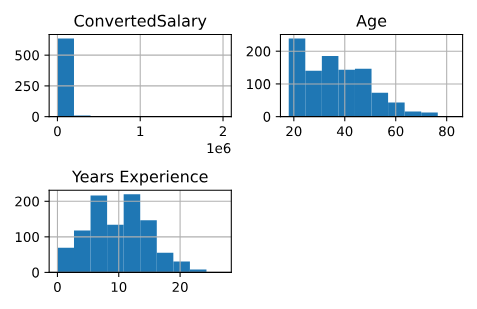

In [ ]:
Generate box plots of the Age and Years Experience columns in the so_numeric_df DataFrame.



In [ ]:
# Create a boxplot of two columns
so_numeric_df[['Age', 'Years Experience']].boxplot()
plt.show()

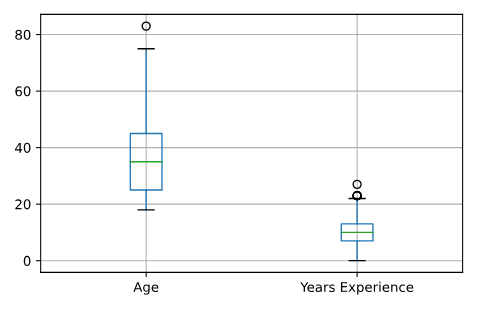

In [ ]:
Generate a box plot of the ConvertedSalary column in the so_numeric_df DataFrame.




In [ ]:
# Create a boxplot of ConvertedSalary
so_numeric_df[["ConvertedSalary"]].boxplot()
plt.show()

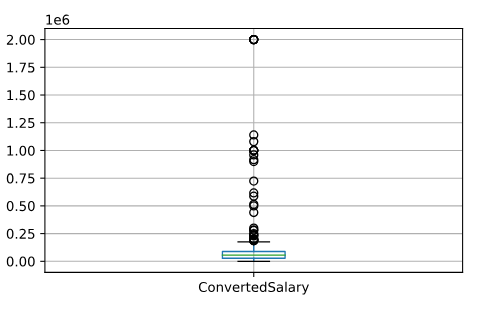

In [ ]:
/
/




Daily XP
1578
Exercise
Exercise
What does your data look like? (II)
In the previous exercise you looked at the distribution of individual columns. While this is a good start, a more detailed view of how different features interact with each other may be useful as this can impact your decision on what to transform and how.

Instructions 1/2
50 XP
1
2
Import matplotlib's pyplot module as plt.
Import seaborn as sns.
Plot pairwise relationships in the so_numeric_df dataset.
Show the plot.

Take Hint (-15 XP)
script.py
123456789
# Import packages
____
____

# Plot pairwise relationships
____

# Show plot
____
IPython Shell
Slides
In [1]:


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot pairwise relationships
sns.pairplot(so_numeric_df)

# Show plot
plt.show()


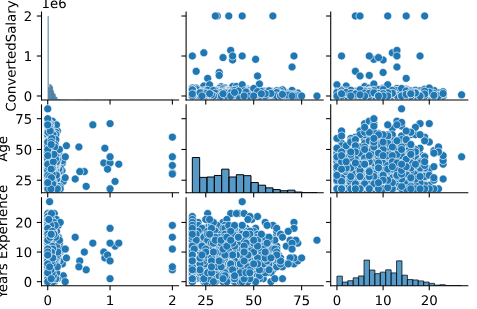

In [ ]:
Print the summary statistics of the so_numeric_df DataFrame.




In [ ]:
# Print summary statistics
print(so_numeric_df.describe())

In [ ]:
/
/




Daily XP
1663
When don't you have to transform your data?
While making sure that all of your data is on the same scale is advisable for most analyses, for which of the following machine learning models is normalizing data not always necessary?

Answer the question
50XP
Possible Answers
Select one answer

K-Means
Press
1

Decision Trees
Press
2

Linear Regression
Press
3

K-nearest neighbors
Press
4

Take Hint (-15 XP)

Submit Answer


In [ ]:
Decision Trees
Press
2

In [ ]:
Correct! As decision trees split along a singular point, they do not require all the columns to be on the same scale.



In [ ]:
/
/




Daily XP
1713
Exercise
Exercise
Normalization
As discussed in the video, in normalization you linearly scale the entire column between 0 and 1, with 0 corresponding with the lowest value in the column, and 1 with the largest.
When using scikit-learn (the most commonly used machine learning library in Python) you can use a MinMaxScaler to apply normalization. (It is called this as it scales your values between a minimum and maximum value.)

Instructions
100 XP
Import MinMaxScaler from sklearn's preprocessing module.
Instantiate the MinMaxScaler() as MM_scaler.
Fit the MinMaxScaler on the Age column of so_numeric_df.
Transform the same column with the scaler you just fit.

Take Hint (-30 XP)
script.py
1234567891011121314
# Import MinMaxScaler
____

# Instantiate MinMaxScaler
MM_scaler = ____()

# Fit MM_scaler to the data
____.____(so_numeric_df[['Age']])

# Transform the data using the fitted scaler

IPython Shell
Slides
In [1]:


In [ ]:
# Import MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

# Instantiate MinMaxScaler
MM_scaler = MinMaxScaler()

# Fit MM_scaler to the data
MM_scaler.fit(so_numeric_df[['Age']])

# Transform the data using the fitted scaler
so_numeric_df['Age_MM'] = MM_scaler.transform(so_numeric_df[['Age']])

# Compare the origional and transformed column
print(so_numeric_df[['Age_MM', 'Age']].head())

In [ ]:
/
/




Daily XP
1813
Exercise
Exercise
Standardization
While normalization can be useful for scaling a column between two data points, it is hard to compare two scaled columns if even one of them is overly affected by outliers. One commonly used solution to this is called standardization, where instead of having a strict upper and lower bound, you center the data around its mean, and calculate the number of standard deviations away from mean each data point is.

Instructions
100 XP
Import StandardScaler from sklearn's preprocessing module.
Instantiate the StandardScaler() as SS_scaler.
Fit the StandardScaler on the Age column of so_numeric_df.
Transform the same column with the scaler you just fit.

Take Hint (-30 XP)
script.py
1234567891011121314
# Import StandardScaler
____

# Instantiate StandardScaler
SS_scaler = ____()

# Fit SS_scaler to the data
____.____(so_numeric_df[['Age']])

# Transform the data using the fitted scaler

IPython Shell
Slides
In [1]:


In [ ]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Instantiate StandardScaler
SS_scaler = StandardScaler()

# Fit SS_scaler to the data
SS_scaler.fit(so_numeric_df[['Age']])

# Transform the data using the fitted scaler
so_numeric_df['Age_SS'] = SS_scaler.transform(so_numeric_df[['Age']])

# Compare the origional and transformed column
print(so_numeric_df[['Age_SS', 'Age']].head())

In [ ]:
/
/




Daily XP
1913
Exercise
Exercise
Log transformation
In the previous exercises you scaled the data linearly, which will not affect the data's shape. This works great if your data is normally distributed (or closely normally distributed), an assumption that a lot of machine learning models make. Sometimes you will work with data that closely conforms to normality, e.g the height or weight of a population. On the other hand, many variables in the real world do not follow this pattern e.g, wages or age of a population. In this exercise you will use a log transform on the ConvertedSalary column in the so_numeric_df DataFrame as it has a large amount of its data centered around the lower values, but contains very high values also. These distributions are said to have a long right tail.

Instructions
100 XP
Import PowerTransformer from sklearn's preprocessing module.
Instantiate the PowerTransformer() as pow_trans.
Fit the PowerTransformer on the ConvertedSalary column of so_numeric_df.
Transform the same column with the scaler you just fit.

Take Hint (-30 XP)
script.py
12345678910111213
# Import PowerTransformer
from sklearn.preprocessing import ____

# Instantiate PowerTransformer
pow_trans = ____

# Train the transform on the data
____

# Apply the power transform to the data

IPython Shell
Slides
In [1]:


In [ ]:
# Import PowerTransformer
from sklearn.preprocessing import PowerTransformer

# Instantiate PowerTransformer
pow_trans = PowerTransformer()

# Train the transform on the data
pow_trans.fit(so_numeric_df[['ConvertedSalary']])

# Apply the power transform to the data
so_numeric_df['ConvertedSalary_LG'] = pow_trans.transform(so_numeric_df[['ConvertedSalary']])

# Plot the data before and after the transformation
so_numeric_df[['ConvertedSalary', 'ConvertedSalary_LG']].hist()
plt.show()

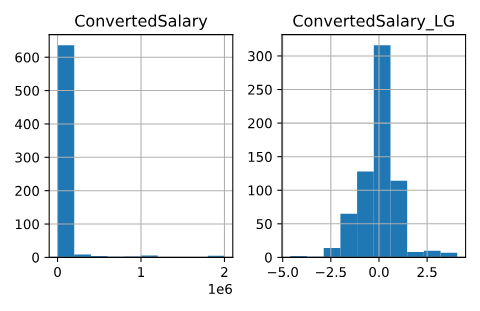

In [ ]:
Superb! Did you notice the change in the shape of the distribution? ConvertedSalary_LG column looks much more normal than the original ConvertedSalary column.



In [ ]:
/
/




Daily XP
2013
When can you use normalization?
When could you use normalization (MinMaxScaler) when working with a dataset?

Answer the question
50XP
Possible Answers
Select one answer

When you know that your data may have outliers.
Press
1

When you know the the data has a strict upper and lower bound.
Press
2

When you know that your test data may contain smaller values than your training data.
Press
3

When you know that your test data may contain larger values than your training data.
Press
4

Take Hint (-15 XP)

Submit Answer


In [ ]:
When you know the the data has a strict upper and lower bound.
Press
2


In [ ]:
/
/




Daily XP
2063
Exercise
Exercise
Percentage based outlier removal
One way to ensure a small portion of data is not having an overly adverse effect is by removing a certain percentage of the largest and/or smallest values in the column. This can be achieved by finding the relevant quantile and trimming the data using it with a mask. This approach is particularly useful if you are concerned that the highest values in your dataset should be avoided. When using this approach, you must remember that even if there are no outliers, this will still remove the same top N percentage from the dataset.

Instructions
100 XP
Find the 95th quantile of the ConvertedSalary column.
Trim the so_numeric_df DataFrame to retain all rows where ConvertedSalary is less than it's 95th quantile.
Plot the histogram of so_numeric_df[['ConvertedSalary']].
Plot the histogram of trimmed_df[['ConvertedSalary']].

Take Hint (-30 XP)
script.py
1234567891011121314
# Find the 95th quantile
quantile = so_numeric_df['ConvertedSalary'].____(____)

# Trim the outliers
trimmed_df = so_numeric_df[so_numeric_df['ConvertedSalary'] < ____]

# The original histogram
so_numeric_df[['ConvertedSalary']].____()
plt.show()
plt.clf()

IPython Shell
Slides
In [1]:


In [ ]:
# Find the 95th quantile
quantile = so_numeric_df['ConvertedSalary'].quantile(0.95)

# Trim the outliers
trimmed_df = so_numeric_df[so_numeric_df['ConvertedSalary'] < quantile]

# The original histogram
so_numeric_df[['ConvertedSalary']].hist()
plt.show()
plt.clf()

# The trimmed histogram
trimmed_df[['ConvertedSalary']].hist()
plt.show()

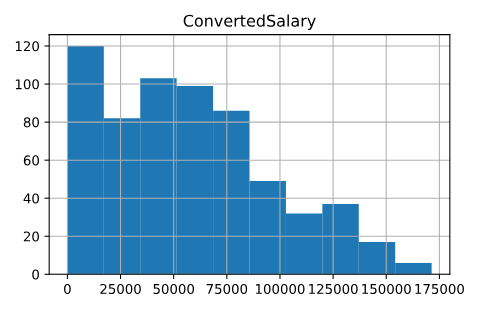

In [ ]:
/
/




Daily XP
2133
Exercise
Exercise
Statistical outlier removal
While removing the top N% of your data is useful for ensuring that very spurious points are removed, it does have the disadvantage of always removing the same proportion of points, even if the data is correct. A commonly used alternative approach is to remove data that sits further than three standard deviations from the mean. You can implement this by first calculating the mean and standard deviation of the relevant column to find upper and lower bounds, and applying these bounds as a mask to the DataFrame. This method ensures that only data that is genuinely different from the rest is removed, and will remove fewer points if the data is close together.

Instructions
100 XP
Calculate the standard deviation and mean of the ConvertedSalary column of so_numeric_df.
Calculate the upper and lower bounds as three standard deviations away from the mean in both the directions.
Trim the so_numeric_df DataFrame to retain all rows where ConvertedSalary is within the lower and upper bounds.

Take Hint (-30 XP)
script.py
12345678910
# Find the mean and standard dev
std = so_numeric_df['ConvertedSalary'].____
mean = so_numeric_df['ConvertedSalary'].____

# Calculate the cutoff
cut_off = std * 3
lower, upper = mean -
Plots
plot
1/1
IPython Shell
Slides
In [1]:


In [ ]:
# Find the mean and standard dev
std = so_numeric_df['ConvertedSalary'].std()
mean = so_numeric_df['ConvertedSalary'].mean()

# Calculate the cutoff
cut_off = std * 3
lower, upper = mean - cut_off, mean + cut_off

# Trim the outliers
trimmed_df = so_numeric_df[(so_numeric_df['ConvertedSalary'] < upper) & (so_numeric_df['ConvertedSalary'] > lower)]

# The trimmed box plot
trimmed_df[['ConvertedSalary']].boxplot()
plt.show()

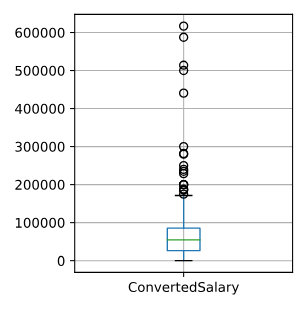

In [ ]:
/
/




Daily XP
2203
Exercise
Exercise
Train and testing transformations (I)
So far you have created scalers based on a column, and then applied the scaler to the same data that it was trained on. When creating machine learning models you will generally build your models on historic data (train set) and apply your model to new unseen data (test set). In these cases you will need to ensure that the same scaling is being applied to both the training and test data.
To do this in practice you train the scaler on the train set, and keep the trained scaler to apply it to the test set. You should never retrain a scaler on the test set.

For this exercise and the next, we split the so_numeric_df DataFrame into train (so_train_numeric) and test (so_test_numeric) sets.

Instructions
100 XP
Instantiate the StandardScaler() as SS_scaler.
Fit the StandardScaler on the Age column.
Transform the Age column in the test set (so_test_numeric).

Take Hint (-30 XP)
script.py
123456789101112
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Apply a standard scaler to the data
SS_scaler = ____

# Fit the standard scaler to the data
____

# Transform the test data using the fitted scaler

IPython Shell
Slides
In [1]:


In [ ]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Apply a standard scaler to the data
SS_scaler = StandardScaler()

# Fit the standard scaler to the data
SS_scaler.fit(so_train_numeric[['Age']])

# Transform the test data using the fitted scaler
so_test_numeric['Age_ss'] = SS_scaler.transform(so_test_numeric[['Age']])
print(so_test_numeric[['Age', 'Age_ss']].head())

In [ ]:
<script.py> output:
         Age  Age_ss
    700   35  -0.091
    701   18  -1.397
    702   47   0.830
    703   57   1.599
    704   41   0.370

In [ ]:
/
/




Daily XP
2203
Exercise
Exercise
Train and testing transformations (II)
Similar to applying the same scaler to both your training and test sets, if you have removed outliers from the train set, you probably want to do the same on the test set as well. Once again you should ensure that you use the thresholds calculated only from the train set to remove outliers from the test set.

Similar to the last exercise, we split the so_numeric_df DataFrame into train (so_train_numeric) and test (so_test_numeric) sets.

Instructions
100 XP
Calculate the standard deviation and mean of the ConvertedSalary column.
Calculate the upper and lower bounds as three standard deviations away from the mean in both the directions.
Trim the so_test_numeric DataFrame to retain all rows where ConvertedSalary is within the lower and upper bounds.

Take Hint (-30 XP)
script.py
123456789
train_std = so_train_numeric['ConvertedSalary'].____
train_mean = so_train_numeric['ConvertedSalary'].____

cut_off = train_std * 3
train_lower, train_upper = ____, train_mean + cut_off

# Trim the test DataFrame
trimmed_df = so_test_numeric[(so_test_numeric['ConvertedSalary'] < ____) \
                             & (so_test_numeric['ConvertedSalary'] >
IPython Shell
Slides
In [1]:


In [ ]:
train_std = so_train_numeric['ConvertedSalary'].std()
train_mean = so_train_numeric['ConvertedSalary'].mean()

cut_off = train_std * 3
train_lower, train_upper = train_mean - cut_off, train_mean + cut_off

# Trim the test DataFrame
trimmed_df = so_test_numeric[(so_test_numeric['ConvertedSalary'] < train_upper) & (so_test_numeric['ConvertedSalary'] > train_lower)]

In [ ]:
/
/




Daily XP
2303
Exercise
Exercise
Cleaning up your text
Unstructured text data cannot be directly used in most analyses. Multiple steps need to be taken to go from a long free form string to a set of numeric columns in the right format that can be ingested by a machine learning model. The first step of this process is to standardize the data and eliminate any characters that could cause problems later on in your analytic pipeline.

In this chapter you will be working with a new dataset containing the inaugural speeches of the presidents of the United States loaded as speech_df, with the speeches stored in the text column.

Instructions 1/2
50 XP
1
2
Print the first 5 rows of the text column to see the free text fields.


Take Hint (-15 XP)
script.py
12
# Print the first 5 rows of the text column
print(____)
IPython Shell
Slides
In [1]:


In [ ]:
# Print the first 5 rows of the text column
print(speech_df['text'].head())

In [ ]:
Replace all non letter characters in the text column with a whitespace.
Make all characters in the newly created text_clean column lower case.

In [ ]:
# Replace all non letter characters with a whitespace
speech_df['text_clean'] = speech_df['text'].str.replace('[^a-zA-Z]', ' ')

# Change to lower case
speech_df['text_clean'] = speech_df['text_clean'].str.lower()

# Print the first 5 rows of the text_clean column
print(speech_df['text_clean'].head())

In [ ]:
/
/




Daily XP
2353
Exercise
Exercise
High level text features
Once the text has been cleaned and standardized you can begin creating features from the data. The most fundamental information you can calculate about free form text is its size, such as its length and number of words. In this exercise (and the rest of this chapter), you will focus on the cleaned/transformed text column (text_clean) you created in the last exercise.

Instructions
100 XP
Record the character length of each speech in the char_count column.
Record the word count of each speech in the word_count column.
Record the average word length of each speech in the avg_word_length column.

Take Hint (-30 XP)
script.py
1234567891011
# Find the length of each text
speech_df['char_cnt'] = speech_df['text_clean'].____

# Count the number of words in each text
speech_df['word_cnt'] = speech_df['text_clean'].____

# Find the average length of word
speech_df['avg_word_length'] = ____ / ____

# Print the first 5 rows of these columns

IPython Shell
Slides
In [1]:


In [ ]:
# Find the length of each text
speech_df['char_cnt'] = speech_df['text_clean'].str.len()

# Count the number of words in each text
speech_df['word_cnt'] = speech_df['text_clean'].str.split().str.len()

# Find the average length of word
speech_df['avg_word_length'] = speech_df['char_cnt'] / speech_df['word_cnt']

# Print the first 5 rows of these columns
print(speech_df[['text_clean', 'char_cnt', 'word_cnt', 'avg_word_length']])

In [ ]:
These features may appear basic but can be quite useful in ML models.

In [ ]:
/
/




Daily XP
2453
Exercise
Exercise
Counting words (I)
Once high level information has been recorded you can begin creating features based on the actual content of each text. One way to do this is to approach it in a similar way to how you worked with categorical variables in the earlier lessons.

For each unique word in the dataset a column is created.
For each entry, the number of times this word occurs is counted and the count value is entered into the respective column.
These "count" columns can then be used to train machine learning models.

Instructions
100 XP
Import CountVectorizer from sklearn.feature_extraction.text.
Instantiate CountVectorizer and assign it to cv.
Fit the vectorizer to the text_clean column.
Print the feature names generated by the vectorizer.

Take Hint (-30 XP)
script.py
1234567891011
# Import CountVectorizer
____

# Instantiate CountVectorizer
cv = ____

# Fit the vectorizer
cv.____(speech_df['text_clean'])

# Print feature names

IPython Shell
Slides
In [1]:


In [ ]:
# Import CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer

# Instantiate CountVectorizer
cv = CountVectorizer()

# Fit the vectorizer
cv.fit(speech_df['text_clean'])

# Print feature names
print(cv.get_feature_names())

In [ ]:
/
/




Daily XP
2523
Exercise
Exercise
Counting words (II)
Once the vectorizer has been fit to the data, it can be used to transform the text to an array representing the word counts. This array will have a row per block of text and a column for each of the features generated by the vectorizer that you observed in the last exercise.

The vectorizer to you fit in the last exercise (cv) is available in your workspace.

Instructions 1/2
50 XP
1
2
Apply the vectorizer to the text_clean column.
Convert this transformed (sparse) array into a numpy array with counts.

Take Hint (-15 XP)
script.py
123456
# Apply the vectorizer
cv_transformed = ____(speech_df['text_clean'])

# Print the full array
cv_array = ____
print(cv_array)
IPython Shell
Slides
In [1]:


In [ ]:
# Apply the vectorizer
cv_transformed = cv.transform(speech_df['text_clean'])

# Print the full array
cv_array = cv_transformed.toarray()
print(cv_array)

In [ ]:
Print the dimensions of this numpy array.




In [ ]:
# Apply the vectorizer
cv_transformed = cv.transform(speech_df['text_clean'])

# Print the full array
cv_array = cv_transformed.toarray()

# Print the shape of cv_array
print(cv_array.shape)

In [ ]:
<script.py> output:
    (58, 9043)

In [ ]:
The speeches have 9043 unique words, which is a lot! In the next exercise, you will see how to create a limited set of features.

In [ ]:
/
/




Daily XP
2623
Exercise
Exercise
Limiting your features
As you have seen, using the CountVectorizer with its default settings creates a feature for every single word in your corpus. This can create far too many features, often including ones that will provide very little analytical value.

For this purpose CountVectorizer has parameters that you can set to reduce the number of features:

min_df : Use only words that occur in more than this percentage of documents. This can be used to remove outlier words that will not generalize across texts.
max_df : Use only words that occur in less than this percentage of documents. This is useful to eliminate very common words that occur in every corpus without adding value such as "and" or "the".
Instructions
100 XP
Limit the number of features in the CountVectorizer by setting the minimum number of documents a word can appear to 20% and the maximum to 80%.
Fit and apply the vectorizer on text_clean column in one step.
Convert this transformed (sparse) array into a numpy array with counts.
Print the dimensions of the new reduced array.

Take Hint (-30 XP)
script.py
123456789101112
# Import CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer

# Specify arguements to limit the number of features generated
cv = ____

# Fit, transform, and convert into array
cv_transformed = ____(speech_df['text_clean'])
cv_array = ____


IPython Shell
Slides
In [1]:


In [ ]:
# Import CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer

# Specify arguements to limit the number of features generated
cv = CountVectorizer(min_df=0.2, max_df=0.8)

# Fit, transform, and convert into array
cv_transformed = cv.fit_transform(speech_df['text_clean'])
cv_array = cv_transformed.toarray()

# Print the array shape
print(cv_array.shape)

In [ ]:
Did you notice that the number of features (unique words) greatly reduced from 9043 to 818?

In [ ]:
<script.py> output:
    (58, 818)

In [ ]:
/
/




Daily XP
2723
Exercise
Exercise
Text to DataFrame
Now that you have generated these count based features in an array you will need to reformat them so that they can be combined with the rest of the dataset. This can be achieved by converting the array into a pandas DataFrame, with the feature names you found earlier as the column names, and then concatenate it with the original DataFrame.

The numpy array (cv_array) and the vectorizer (cv) you fit in the last exercise are available in your workspace.

Instructions
100 XP
Create a DataFrame cv_df containing the cv_array as the values and the feature names as the column names.
Add the prefix Counts_ to the column names for ease of identification.
Concatenate this DataFrame (cv_df) to the original DataFrame (speech_df) column wise.

Take Hint (-30 XP)
script.py
1234567
# Create a DataFrame with these features
cv_df = pd.DataFrame(____,
                     columns=____).____('Counts_')

# Add the new columns to the original DataFrame
speech_df_new = ____([speech_df, cv_df], axis=1, sort=False)
print(speech_df_new.head())
IPython Shell
Slides
In [1]:


In [ ]:
# Create a DataFrame with these features
cv_df = pd.DataFrame(cv_array,
                     columns=cv.get_feature_names_out()).add_prefix('Counts_')

# Add the new columns to the original DataFrame
speech_df_new = pd.concat([speech_df, cv_df], axis=1, sort=False)
print(speech_df_new.head())

In [ ]:
/
/




Daily XP
2823
Exercise
Exercise
Tf-idf
While counts of occurrences of words can be useful to build models, words that occur many times may skew the results undesirably. To limit these common words from overpowering your model a form of normalization can be used. In this lesson you will be using Term frequency-inverse document frequency (Tf-idf) as was discussed in the video. Tf-idf has the effect of reducing the value of common words, while increasing the weight of words that do not occur in many documents.

Instructions
100 XP
Import TfidfVectorizer from sklearn.feature_extraction.text.
Instantiate TfidfVectorizer while limiting the number of features to 100 and removing English stop words.
Fit and apply the vectorizer on text_clean column in one step.
Create a DataFrame tv_df containing the weights of the words and the feature names as the column names.

Take Hint (-30 XP)
script.py
12345678910111213
# Import TfidfVectorizer
____

# Instantiate TfidfVectorizer
tv = ____

# Fit the vectroizer and transform the data
tv_transformed = ____(speech_df['text_clean'])

# Create a DataFrame with these features

IPython Shell
Slides
In [1]:


In [ ]:
# Import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Instantiate TfidfVectorizer
tv = TfidfVectorizer(max_features=100, stop_words="english")

# Fit the vectroizer and transform the data
tv_transformed = tv.fit_transform(speech_df['text_clean'])

# Create a DataFrame with these features
tv_df = pd.DataFrame(tv_transformed.toarray(),
                     columns=tv.get_feature_names_out()).add_prefix('TFIDF_')
print(tv_df.head())

In [ ]:
A job well done! Did you notice that counting the word occurences and calculating the Tf-idf weights are very similar? This is one of the reasons scikit-learn is very popular, a consistent API.

In [ ]:
/
/




Daily XP
2923
Exercise
Exercise
Inspecting Tf-idf values
After creating Tf-idf features you will often want to understand what are the most highest scored words for each corpus. This can be achieved by isolating the row you want to examine and then sorting the the scores from high to low.

The DataFrame from the last exercise (tv_df) is available in your workspace.

Instructions
100 XP
Assign the first row of tv_df to sample_row.
sample_row is now a series of weights assigned to words. Sort these values to print the top 5 highest-rated words.

Take Hint (-30 XP)
script.py
12345
# Isolate the row to be examined
sample_row = tv_df.____

# Print the top 5 words of the sorted output
print(sample_row.____(ascending=____).____())
IPython Shell
Slides
In [1]:


In [ ]:
# Assign the first row of tv_df to sample_row
sample_row = tv_df.iloc[0]

# Sort the TF-IDF values in descending order and print the top 5 words
top_words = sample_row.sort_values(ascending=False).head(5)
print(top_words)


In [ ]:
<script.py> output:
    TFIDF_government    0.367
    TFIDF_public        0.333
    TFIDF_present       0.315
    TFIDF_duty          0.239
    TFIDF_country       0.230
    Name: 0, dtype: float64

In [ ]:
Do you think these scores make sense for the corresponding words?



In [ ]:
/
/




Daily XP
3023
Exercise
Exercise
Transforming unseen data
When creating vectors from text, any transformations that you perform before training a machine learning model, you also need to apply on the new unseen (test) data. To achieve this follow the same approach from the last chapter: fit the vectorizer only on the training data, and apply it to the test data.

For this exercise the speech_df DataFrame has been split in two:

train_speech_df: The training set consisting of the first 45 speeches.
test_speech_df: The test set consisting of the remaining speeches.
Instructions
100 XP
Instantiate TfidfVectorizer.
Fit the vectorizer and apply it to the text_clean column.
Apply the same vectorizer on the text_clean column of the test data.
Create a DataFrame of these new features from the test set.

Take Hint (-30 XP)
script.py
12345678910111213
# Instantiate TfidfVectorizer
tv = ____(max_features=100, stop_words='english')

# Fit the vectroizer and transform the data
tv_transformed = ____

# Transform test data
test_tv_transformed = ____

# Create new features for the test set

IPython Shell
Slides
In [1]:


In [ ]:
# Instantiate TfidfVectorizer
tv = TfidfVectorizer(max_features=100, stop_words='english')

# Fit the vectroizer and transform the data
tv_transformed = tv.fit_transform(train_speech_df['text_clean'])

# Transform test data
test_tv_transformed = tv.transform(test_speech_df['text_clean'])

# Create new features for the test set
test_tv_df = pd.DataFrame(test_tv_transformed.toarray(),
                          columns=tv.get_feature_names()).add_prefix('TFIDF_')
print(test_tv_df.head())

In [ ]:
/
/




Daily XP
3023
Exercise
Exercise
Using longer n-grams
So far you have created features based on individual words in each of the texts. This can be quite powerful when used in a machine learning model but you may be concerned that by looking at words individually a lot of the context is being ignored. To deal with this when creating models you can use n-grams which are sequence of n words grouped together. For example:

bigrams: Sequences of two consecutive words
trigrams: Sequences of two consecutive words
These can be automatically created in your dataset by specifying the ngram_range argument as a tuple (n1, n2) where all n-grams in the n1 to n2 range are included.

Instructions
100 XP
Import CountVectorizer from sklearn.feature_extraction.text.
Instantiate CountVectorizer while considering only trigrams.
Fit the vectorizer and apply it to the text_clean column in one step.
Print the feature names generated by the vectorizer.

Take Hint (-30 XP)
script.py
12345678910111213
# Import CountVectorizer
from sklearn.feature_extraction.text import ____

# Instantiate a trigram vectorizer
cv_trigram_vec = CountVectorizer(max_features=100,
                                 stop_words='english',
                                 ____)

# Fit and apply trigram vectorizer
cv_trigram = ____(speech_df['text_clean'])

IPython Shell
Slides
In [1]:


In [ ]:
# Import CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer

# Instantiate a trigram vectorizer
cv_trigram_vec = CountVectorizer(max_features=100,
                                 stop_words='english',
                                 ngram_range=(3, 3))

# Fit and apply trigram vectorizer
cv_trigram = cv_trigram_vec.fit_transform(speech_df['text_clean'])

# Print the trigram features
print(cv_trigram_vec.get_feature_names())


In [ ]:
<script.py> output:
    ['ability preserve protect', 'agriculture commerce manufactures', 'america ideal freedom', 'amity mutual concession', 'anchor peace home', 'ask bow heads', 'best ability preserve', 'best interests country', 'bless god bless', 'bless united states', 'chief justice mr', 'children children children', 'citizens united states', 'civil religious liberty', 'civil service reform', 'commerce united states', 'confidence fellow citizens', 'congress extraordinary session', 'constitution does expressly', 'constitution united states', 'coordinate branches government', 'day task people', 'defend constitution united', 'distinction powers granted', 'distinguished guests fellow', 'does expressly say', 'equal exact justice', 'era good feeling', 'executive branch government', 'faithfully execute office', 'fellow citizens assembled', 'fellow citizens called', 'fellow citizens large', 'fellow citizens world', 'form perfect union', 'general welfare secure', 'god bless america', 'god bless god', 'good greatest number', 'government peace war', 'government united states', 'granted federal government', 'great body people', 'great political parties', 'greatest good greatest', 'guests fellow citizens', 'invasion wars powers', 'land new promise', 'laws faithfully executed', 'letter spirit constitution', 'liberty pursuit happiness', 'life liberty pursuit', 'local self government', 'make hard choices', 'men women children', 'mr chief justice', 'mr majority leader', 'mr president vice', 'mr speaker mr', 'mr vice president', 'nation like person', 'new breeze blowing', 'new states admitted', 'north south east', 'oath prescribed constitution', 'office president united', 'passed generation generation', 'peace shall strive', 'people united states', 'physical moral political', 'policy united states', 'power general government', 'preservation general government', 'preservation sacred liberty', 'preserve protect defend', 'president united states', 'president vice president', 'promote general welfare', 'proof confidence fellow', 'protect defend constitution', 'protection great interests', 'reform civil service', 'reserved states people', 'respect individual human', 'right self government', 'secure blessings liberty', 'south east west', 'sovereignty general government', 'states admitted union', 'territories united states', 'thank god bless', 'turning away old', 'united states america', 'united states best', 'united states government', 'united states great', 'united states maintain', 'united states territory', 'vice president mr', 'welfare secure blessings']

In [ ]:
/
/




Daily XP
3123
Exercise
Exercise
Finding the most common words
Its always advisable once you have created your features to inspect them to ensure that they are as you would expect. This will allow you to catch errors early, and perhaps influence what further feature engineering you will need to do.

The vectorizer (cv) you fit in the last exercise and the sparse array consisting of word counts (cv_trigram) is available in your workspace.

Instructions
100 XP
Create a DataFrame of the features (word counts).
Add the counts of word occurrences and print the top 5 most occurring words.

Take Hint (-30 XP)
script.py
123456
# Create a DataFrame of the features
cv_tri_df = ____(____,
                 columns=cv_trigram_vec.get_feature_names()).add_prefix('Counts_')

# Print the top 5 words in the sorted output
print(cv_tri_df.sum().____(ascending=____).head())
IPython Shell
Slides
In [1]:


In [ ]:
# Create a DataFrame of the features
cv_tri_df = pd.DataFrame(cv_trigram.toarray(),
                 columns=cv_trigram_vec.get_feature_names()).add_prefix('Counts_')

# Print the top 5 words in the sorted output
print(cv_tri_df.sum().sort_values(ascending=False).head())

In [ ]:
<script.py> output:
    Counts_constitution united states    20
    Counts_people united states          13
    Counts_mr chief justice              10
    Counts_preserve protect defend       10
    Counts_president united states        8
    dtype: int64

In [ ]:
Great, that the most common trigram is constitution united states makes a lot of sense for US presidents speeches.

